In [1]:
%cd ..

import sys
import os

from driverEngine import driverEngine
from utils.data_utils import load_config
import matplotlib.pyplot as plt
import numpy as np
from utils.caption_utils import parse_string
import cv2
import matplotlib.pyplot as plt

/home/ximeng/anaconda3/envs/dllm/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ximeng/Documents/NaviDrive


In [6]:
from nuscenes.nuscenes import NuScenes
version = "v1.0-trainval"
nuscenes_dataroot = "/home/ximeng/Dataset/nuscenes_full_v1_0/"
nusc = NuScenes(version=version, dataroot=nuscenes_dataroot, verbose=False)

In [2]:
config_path = "configs/qwen_vl_2B_sft_cmd_img.yaml"

config = load_config(config_path)
trainer = driverEngine(config)
trainer.load_model_from_checkpoint()

Loading model from checkpoint: checkpoints/qwen_vl_2B_sft_cmd_img
Loading visual model: checkpoints/qwen_vl_2B_sft_cmd_img with attention: flash_attention_2


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Model loaded successfully from checkpoint.


In [97]:
def plot_six_views_by_token(nusc, token):
    """
    Given a sample token, retrieves and plots the 6 original camera images 
    from the nuScenes dataset individually using matplotlib.
    """
    # 1. Retrieve the sample record using the provided token
    sample_rec = nusc.get('sample', token)
    
    # 2. Define the standard 6 camera channels in nuScenes
    camera_channels = [
        'CAM_FRONT', 
        'CAM_FRONT_RIGHT', 
        'CAM_FRONT_LEFT', 
        'CAM_BACK', 
        'CAM_BACK_LEFT', 
        'CAM_BACK_RIGHT'
    ]
    
    print(f"--- Processing Token: {token} ---")
    
    # 3. Iterate through each camera channel
    for channel in camera_channels:
        # Get the sample_data token for the specific camera
        sd_token = sample_rec['data'][channel]
        sd_rec = nusc.get('sample_data', sd_token)
        
        # Construct the absolute path to the image file
        # nusc.dataroot is the base directory of your dataset
        img_path = os.path.join(nusc.dataroot, sd_rec['filename'])
        
        # 4. Read and display the image
        if os.path.exists(img_path):
            # OpenCV reads in BGR format; convert to RGB for correct matplotlib display
            img_bgr = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            # Create a new figure for each image to print them separately
            plt.figure(figsize=(12, 7))
            plt.imshow(img_rgb)
            
            # Add title with channel name and relative file path
            # plt.title(f"Sensor: {channel}\nFile: {sd_rec['filename']}", fontsize=12)
            
            # Remove axis ticks for a cleaner look
            plt.axis('off')
            
            # Render the plot immediately
            plt.show()
        else:
            print(f"Warning: Image file not found at {img_path}")

In [167]:
def plot_debug_results(pred_outputs, gt_wp_raw, command="Unknown"):
    """
    Plots multiple trajectory candidates against the ground truth, 
    calculates ADE for each, and returns the best performing trajectory.
    """
    plt.figure(figsize=(11, 8))
    
    # 1. Parse Ground Truth trajectory
    gt_pts = parse_string(gt_wp_raw)
    gt_x = gt_pts[:, 0]
    gt_y = gt_pts[:, 1]
    
    # Plot Ground Truth as a thick black line with diamond markers
    plt.plot(gt_x, gt_y, color='black', marker='D', markersize=6, 
             linewidth=3, label='Ground Truth', zorder=10)

    # Define distinct colors for up to 6 candidate trajectories
    colors = ['#FF0000', '#00FF00', '#0000FF', '#FF00FF', '#00FFFF', '#FFA500']
    
    ade_list = []
    parsed_trajectories = [] # List to store numpy arrays of parsed candidates

    # 2. Iterate through each predicted candidate string
    for i, raw_str in enumerate(pred_outputs):
        try:
            # Convert string output to numpy array [N, 2]
            pred_pts = parse_string(raw_str)
            parsed_trajectories.append(pred_pts) # Store for later retrieval
            
            px = pred_pts[:, 0]
            py = pred_pts[:, 1]
            
            # Align lengths to calculate error (Euclidean distance)
            min_len = min(len(gt_pts), len(pred_pts))
            if min_len == 0:
                ade_list.append(float('inf'))
                continue
                
            # Calculate Average Displacement Error (ADE)
            errors = np.sqrt((px[:min_len] - gt_x[:min_len])**2 + (py[:min_len] - gt_y[:min_len])**2)
            ade = np.mean(errors)
            ade_list.append(ade)

            # Plot each candidate with a unique color and dashed line
            plt.plot(px, py, color=colors[i], linestyle='--', marker='.', 
                     alpha=0.7, label=f'C{i+1} (ADE: {ade:.2f}m)')
            
        except Exception as e:
            print(f"Trajectory parsing error for candidate {i+1} : {e}")
            ade_list.append(float('inf'))
            parsed_trajectories.append(None)

    # 3. Identify the best trajectory (minimum ADE)
    best_trajectory_np = None
    min_ade = float('inf')

    if ade_list and any(ade != float('inf') for ade in ade_list):
        min_ade = min(ade_list)
        # Find index of the trajectory with the lowest ADE
        best_idx = np.argmin(ade_list) 
        best_trajectory_np = parsed_trajectories[best_idx]
        
        # Display the minADE value on the plot
        stats_text = f'minADE: {min_ade:.4f} m'
        plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, 
                 fontsize=12, fontweight='bold', va='bottom', ha='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 4. Finalize plot styling
    plt.axhline(0, color='gray', linewidth=0.5, alpha=0.5) # X-axis
    plt.axvline(0, color='gray', linewidth=0.5, alpha=0.5) # Y-axis
    plt.xlabel('Lateral Distance X (m)')
    plt.ylabel('Longitudinal Distance Y (m)')
    
    plt.title(f"Trajectory Debug [Command: {command}]\nminADE: {min_ade:.4f}m")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Candidates")
    plt.axis('equal') # Maintain 1:1 aspect ratio for spatial accuracy
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Returns the scalar ADE value and the best trajectory as a NumPy array
    return min_ade, best_trajectory_np


============================== PROMPT ==============================
Perception: The ego-vehicle is traveling slowly (3.37 m/s) on a wet road, likely in light rain, given the visible water droplets on the windshield and reflective road surface. The front view shows a dark sedan ahead with brake lights on, indicating a slow-down or stop. The road appears two-lane with visible lane markings. On the right, a white taxi (NeuroCab) is visible, partially in the adjacent lane. The left side features a concrete barrier with railings and trees. Parked vehicles are visible on both sides. No traffic signals or signs are clearly visible in the front. The lateral acceleration is negligible, and the yaw rate is zero, indicating straight-line motion with no current turn.

Action: Continue decelerating at a moderate rate and maintain current lane position.

Reasoning: The vehicle ahead is braking, as indicated by its illuminated brake lights, and the ego-vehicle is already decelerating (negative long

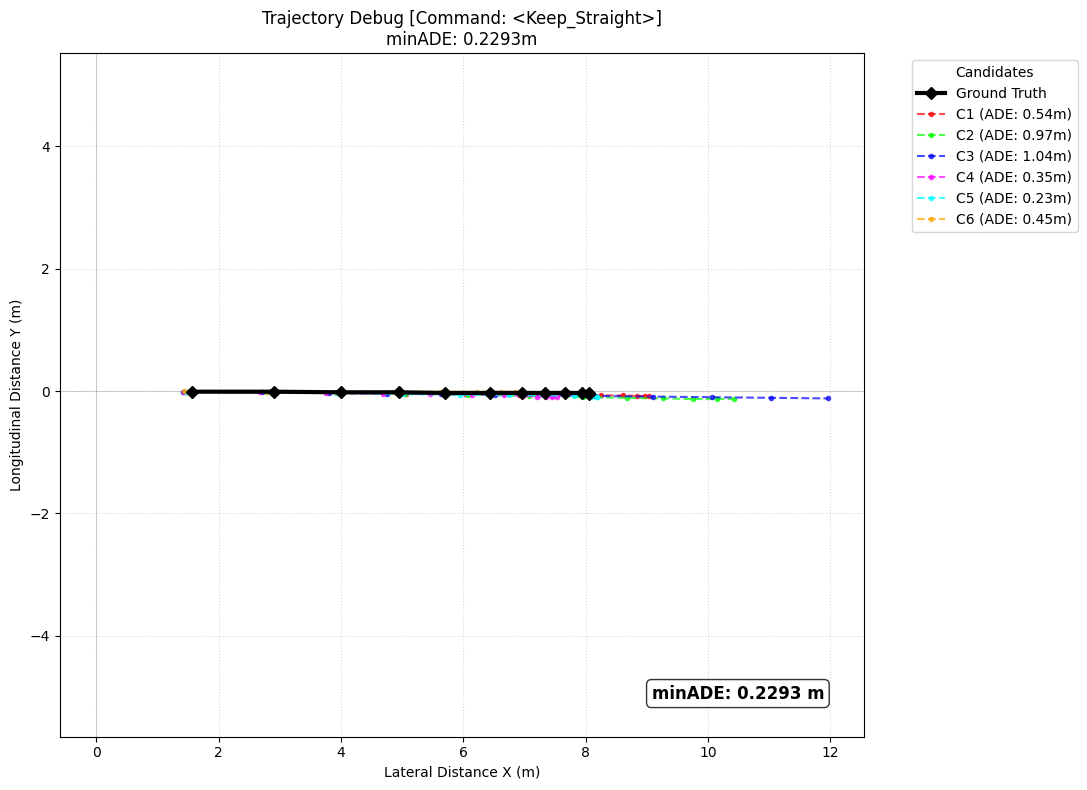

In [168]:
outputs, gt_wp, command, token = trainer.inference_once(temperature=0.7, top_p=0.8, sample_index=41)
min_ade, best_trajectory = plot_debug_results(outputs, gt_wp, command)

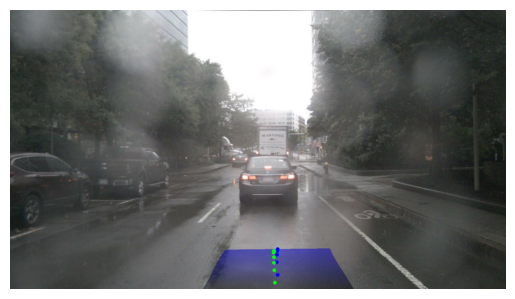

In [169]:
from utils.results_utils import project_wp_to_image

sample_token = token[0]
# plot_six_views_by_token(nusc, sample_token)

sample_record = nusc.get('sample', sample_token)
cam_front_token = sample_record['data']['CAM_FRONT']
cam_data = nusc.get('sample_data', cam_front_token)
image_path = os.path.join(nusc.dataroot, cam_data['filename'])
front_img = cv2.imread(image_path)
# vis_img = project_wp_to_image(nusc, sample_token, best_trajectory, front_img)
vis_img = project_wp_to_image(
    nusc, sample_token, best_trajectory, front_img,
    color_waypoints=(255, 0, 0),
    color_polygon=(200, 0, 0),
    plot_polygon=True
)
gt_pts_str = parse_string(gt_wp)
gt_x = gt_pts_str[:, 0]
gt_y = gt_pts_str[:, 1]
gt_pts = np.column_stack((gt_x, gt_y))
vis_img = project_wp_to_image(
    nusc, sample_token, gt_pts, vis_img,
    color_waypoints=(0, 255, 0),
    plot_polygon=False
)


# IMPORTANT: Convert BGR (OpenCV) to RGB (Matplotlib)
vis_img_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)

plt.imshow(vis_img_rgb)
plt.axis('off') # Hide coordinate axes
plt.show()